<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/Datatransformation_assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.
#Dataset:
#Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.
#Tasks:
#1.	Handle missing values as per the best practices (imputation, removal, etc.).
    #●	Apply scaling techniques to numerical features:
        #a.	Standard Scaling   b. Min-Max Scaling
     #●	Discuss the scenarios where each scaling technique is preferred and why.
#2. Encoding Techniques:
    #●	Apply One-Hot Encoding to categorical variables with less than 5 categories.
    #●	Use Label Encoding for categorical variables. Data Exploration and Preprocessing:
    #●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).
    #●	les with more than 5 categories.
    #●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.
# 3. Feature Engineering:
    #●	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.
    #●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/adult_with_headers (1).csv')

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.shape

(32561, 15)

In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
df = df.replace("?", np.nan)

In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
categorical_columns = [
    "workclass",
    'education',
    'marital_status',
    'relationship',
    'race',
    'sex',
    "occupation",
    "native_country"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    #is used to handle and fill missing (null) values in the above categorical columns.

In [12]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
num_col = ['age',	'fnlwgt',	'education_num', 'capital_gain',	'capital_loss','hours_per_week']

In [14]:
std_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[num_col] = std_scaler.fit_transform(df[num_col])

In [15]:
# Centers the distribution to have a mean of 0 and a standard deviation of 1
#Used when algorithms assume data is normally distributed  or rely on distance metrics and optimization gradients, such as Logistic Regression, Support Vector Machines (SVM), and Principal Component Analysis (PCA).
# It handles outliers better than Min-Max scaling because it doesn't squash all data into a rigid, bounded range.

In [16]:
min_max_scaler = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_col] = min_max_scaler.fit_transform(df[num_col])

In [17]:
#Rescales features to a fixed, bounded range, usually between 0 and 1
#Used when algorithms do not make assumptions about the data distribution, or when bounded inputs are specifically required, such as Neural Networks (with activation functions like sigmoid) and K-Nearest Neighbors (KNN).
#It preserves the exact shape of the original distribution and prevents features with massive numerical ranges from dominating algorithms sensitive to tiny variance changes. However, it is highly sensitive to extreme outliers, which can compress the majority of normal values into a very tight band.

In [18]:
cat_cols = ['workclass','education',	'marital_status','occupation',	'relationship',	'race',	'sex',	'native_country']
for col in cat_cols:
    print(col, ":", df[col].nunique())

workclass : 9
education : 16
marital_status : 7
occupation : 15
relationship : 6
race : 5
sex : 2
native_country : 42


In [19]:
onehot_columns = []

for col in cat_cols:
    if df[col].nunique() < 5:
        onehot_columns.append(col)

print(onehot_columns)

['sex']


In [20]:
#We can apply One-Hot Encoding:
df = pd.get_dummies(df, columns=onehot_columns, drop_first=True)
#pd.get_dummies(...): This is the Pandas function used to convert categorical string columns into numerical binary dummy columns (0s and 1s).

In [21]:
from sklearn.preprocessing import LabelEncoder
label_cols = [col for col in cat_cols if col in df.columns and col not in onehot_columns]

# 2. Initialize the LabelEncoder
label_encoder = LabelEncoder()

In [22]:
for col in label_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [23]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,<=50K,True
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,<=50K,True
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,<=50K,True
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,<=50K,True
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,<=50K,False


In [24]:
#Pros and cons of both the encoding techniques:
#One-Hot Encoding converts each category into separate binary columns containing 0 and 1.
#Pros:
#1)It does not imply that one category is greater or smaller than another.
#2)Easy to understand
#3)Works well with ml algorithms
#Cons:
#1)Creates too many columns
#2)Too many columns increase the dimensionality of the dataset, which can make some models slower and less efficient.
#3)Most values in the new columns will be 0, creating a sparse dataset

#Label Encoding converts each category into a numerical value.
#Pros:
#1. Creates only one column
#2. Memory efficient
#3. Useful for ordinal data
#Cons:
#1. Can create a false order
#2. May mislead some algorithms



In [25]:
#Now lets consider the 1st feature
bins = [0, 25, 45, 65, 100]
labels = ['Youth', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [ ]:
#Income earning potential doesn't scale linearly with age; it typically peaks during prime career years
 #(middle age) and tapers off. Grouping ages helps tree-based models split populations more efficiently based on career stage milestones

In [28]:
#2ndnd feature is netcapital
df['net_capital'] = df["capital_gain"] - df["capital_loss"]

In [24]:
#A person's raw capital gain or loss alone doesn't factor in their overall financial volatility. Subtracting losses from gains provides a
#single net investment score that can help models better isolate high-earning potential.

In [34]:
df['log_fnlwgt'] = np.log1p(df['fnlwgt'])

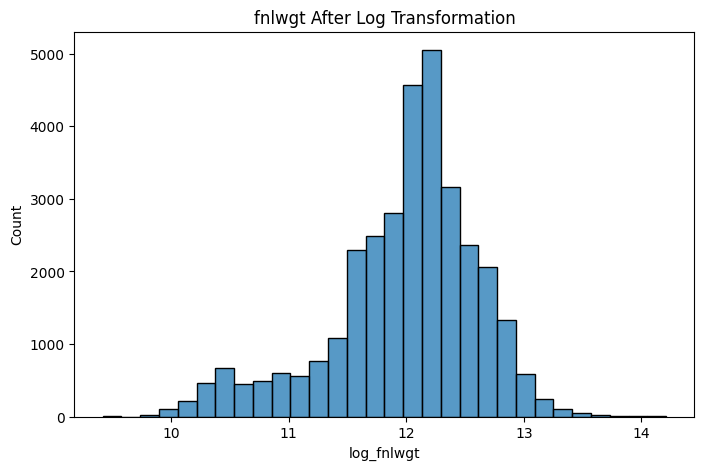

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["log_fnlwgt"],
    bins=30
)

plt.title("fnlwgt After Log Transformation")

plt.show()

In [ ]:
#The column fnlwgt  is chosen because it exhibits severe right-skewness (the vast majority of values are clustered heavily toward the lower end,
#with a long tail of extreme high values). It Compresses Variance and normalizes the distribution.